# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Ejemplo del libro ($z \mapsto z^2$)

## Puntos fijos

Encontramos los puntos fijos:

In [3]:
z = sp.Symbol('z')
fixed_points_equation = sp.Eq(z**2, z)
fixed_points = sp.solve(fixed_points_equation, z)
print(fixed_points)

[0, 1]


Ahora analizamos su comportamiento. Notar que $\infty$ también es un punto fijo.

In [4]:
z = sp.Symbol('z')
R = z**2
R_prime = R.diff(z)
print(R_prime)

2*z


$R'(z) = 2x$

In [5]:
R_prime.subs(z, 0)

0

Cómo $|(R'(0))| = 0 \lt 1 $, $0$ es un punto fijo atractor.

In [6]:
R_prime.subs(z, 1)

2

Cómo $|(R'(1))| = 2 \gt 1 $, $1$ es un punto fijo repulsor.

Analizando el caso de $\infty$ a mano, se puede ver que es atractor.

## Regiones de $\mathbb{C}_\infty$

Primero analizaremos las regiones que van a ser más fáciles, $C_1 = \{z : |z| \lt 1 \}$ y $C_2 = \{z : |z| \gt 1 \}$.

Si tenemos $z \in C_1$, es claro que $R^n(z) \to 0$.

In [41]:
def R(z):
    return z**2

In [8]:
r = np.random.uniform(0, 1)
theta = np.random.uniform(0, 2*np.pi)

z0 = r*np.exp(np.pi*theta*1j)

In [9]:
max_iter = 100
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = -0.43 + -0.48i$'}>

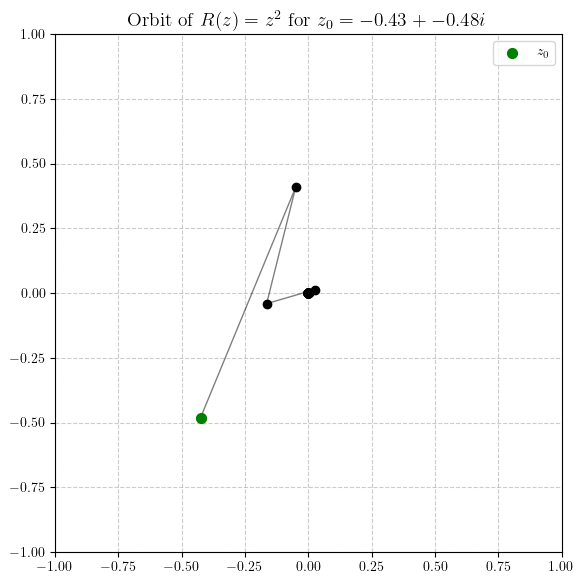

In [10]:
center = 0
max_distance_to_center = 1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Si tenemos $z \in C_2$, es claro que $R^n(z) \to \infty$.

In [11]:
r = np.random.uniform(1, 10)
theta = np.random.uniform(0, 2*np.pi)

z0 = r*np.exp(np.pi*theta*1j)

In [12]:
max_iter = 10
orbit = generate_orbit(z0, R, max_iter=max_iter)

C:\Users\abald\AppData\Local\Temp\ipykernel_16776\1802130496.py:2: RuntimeWarning: overflow encountered in scalar power
  return z**2
C:\Users\abald\AppData\Local\Temp\ipykernel_16776\1802130496.py:2: RuntimeWarning: invalid value encountered in scalar power
  return z**2


In [13]:
index = 1
for z in orbit:
    print(index, ': ', np.abs(z))
    index += 1

1 :  6.591655665967902
2 :  43.449924418686756
3 :  1887.8959319895919
4 :  3564151.0500228493
5 :  12703172707378.982
6 :  1.6137059683349826e+26
7 :  2.604046952239943e+52
8 :  6.781060529470136e+104
9 :  4.5982781904337796e+209
10 :  inf
11 :  nan


Ahora vayamos con el caso interesante, $C = \{z : |z| = 1\}$. Notemos que como $1$ es un punto divergente, la única forma en la que $R^n(z) \to 1$ es si $\exists m$ tal que $R^m(z) = 1$, lo cual equivale a que $z = \exp\left(i \frac{2\pi r}{2^m}\right)$, donde $r$, $m \in \mathbb{N}$. Además, los puntos de esta forma son densos en $C$.

Sin embargo, todos los puntos que no sean de dicha forma (que también son densos en $C$) nunca convergerán en $1$ y tampoco saldrán de $C$. Parte de estos puntos serán puntos periódicos (puntos fijos de $R^n$ para algún $n \in \mathbb{N}$, es decir, $(2^n -1)$-th raíces de la unidad), que son también densos en $C$, y otra parte serán puntos que nunca formarán un ciclo pero tampoco convergerán (que también son densos en $C$), simplemente darán vueltas sin parar y sin nunca repetir un punto, pero siempre dentro de $C$.

Veamos ejemplos para todos estos casos.

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Julia Set (Escape Boundary)'}>)

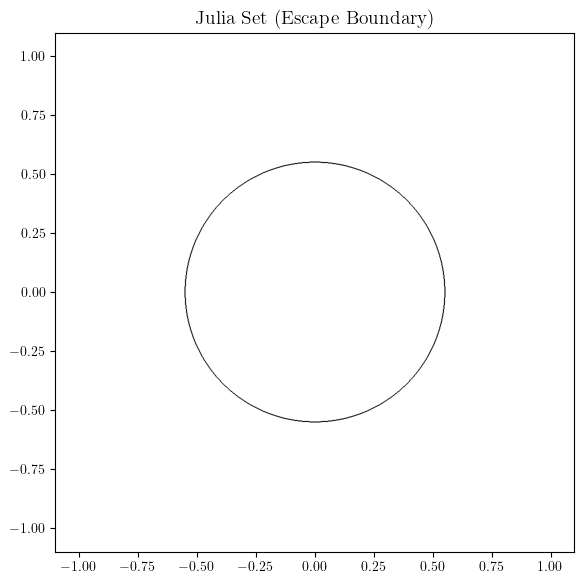

In [43]:
scape_times = generate_escape_time_fractal(-2.0, 2.0, -2.0, 2.0, 1000, 1000, R, max_iter=100, escape_radius=2.0)
plotter.plot_julia_set_from_escape_times(scape_times, max_iter=100)

Punto que converge a 1.

In [20]:
m = int(np.random.uniform(0, 11))
r = int(np.random.uniform(0, 2**m))

z0 = np.exp(2j*np.pi*r/(2**m))

In [21]:
max_iter = m
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = -0.31 + 0.95i$'}>

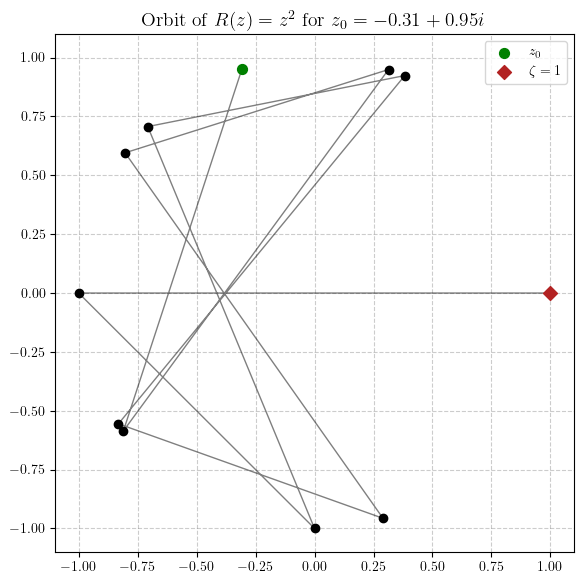

In [22]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)
plotter.add_points(ax, [1], label="$\zeta = 1$", marker='D', color='firebrick', s=50)

Punto cíclico.

In [23]:
n = int(np.random.uniform(0, 11))
r = int(np.random.uniform(0, 2**n - 1))

z0 = np.exp(2j*np.pi*r/(2**n - 1))

In [24]:
max_iter = n
orbit = generate_orbit(z0, R, max_iter=max_iter)

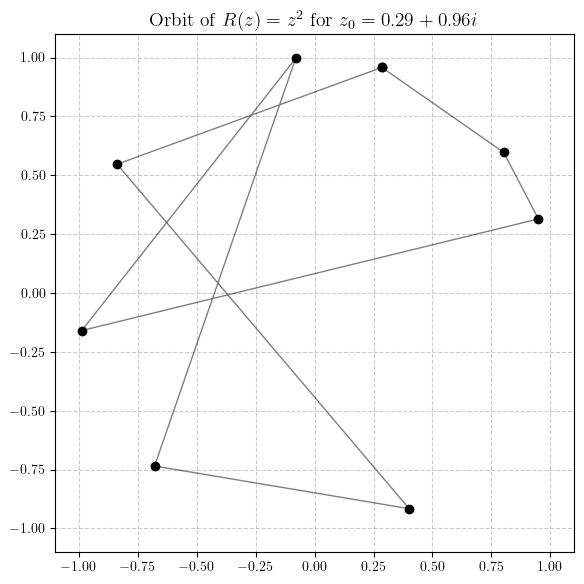

In [25]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)

Punto no cíclico, no convergente. (eligo uno al azar, estadísticamente lo más probable es que sea no cíclico y no convergente)

In [32]:
theta = np.random.uniform(0, 2*np.pi)

z0 = np.exp(1j*theta)

In [33]:
max_iter = 40
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = -0.08 + 1.0i$'}>

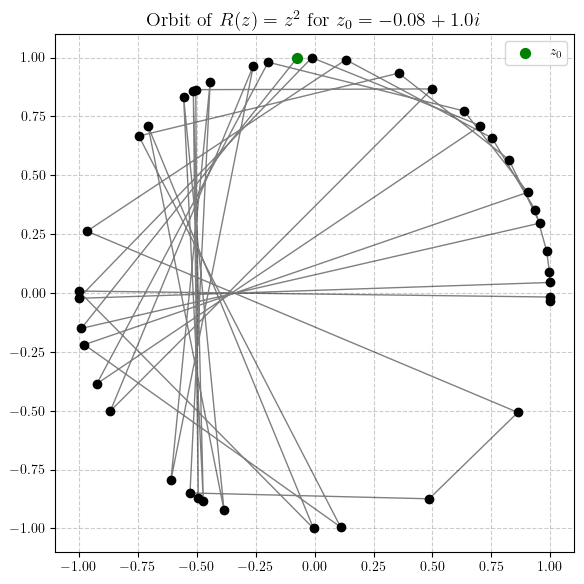

In [34]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

# Ejercicio 1

In [44]:
def R(z):
    return z**-2

Los puntos fijos son $\zeta_1 = 1$, $\zeta_2 = \exp\left(i\frac{2\pi}{3}\right)$, $\zeta_3 = \exp\left(i\frac{4\pi}{3}\right)$. Y son todos repulsores. El comportamiento en la circuferencia unidad centrada en $0$ es quedarse ahí. Fuera de este conjunto los puntos se van alejando cada vez más de la circunferencia unidad centrada en $0$ alternando entre estar dentro y fuera de esta. Es decir, se van acercando de manera alternante al $0$ y al $\infty$.

Punto no fijo en la circunferencia unidad centrada en $0$.

In [45]:
r = 1
theta = np.random.uniform()

z0 = r*np.exp(2j*np.pi*theta)

In [46]:
max_iter = 40
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^-2$ for $z_0 = -0.02 + 1.0i$'}>

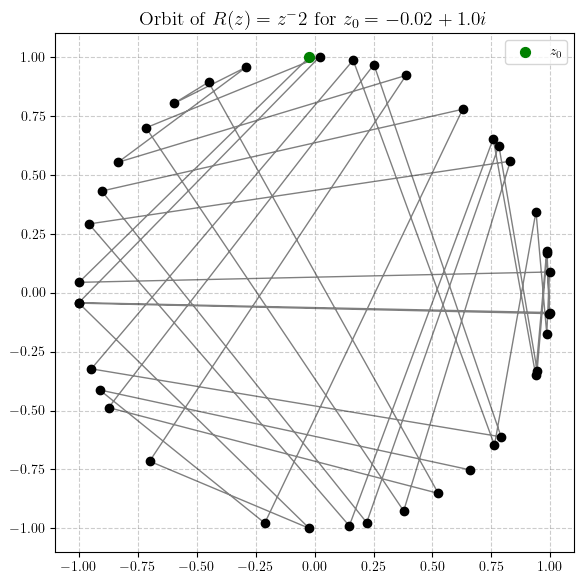

In [47]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^{-2}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

Punto fuera de la circunferencia unidad centrada en $0$.

In [48]:
r = np.random.uniform()
theta = np.random.uniform()

z0 = r*np.exp(2j*np.pi*theta)

In [49]:
max_iter = 10
orbit = generate_orbit(z0, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^-2$ for $z_0 = -0.44 + -0.28i$'}>

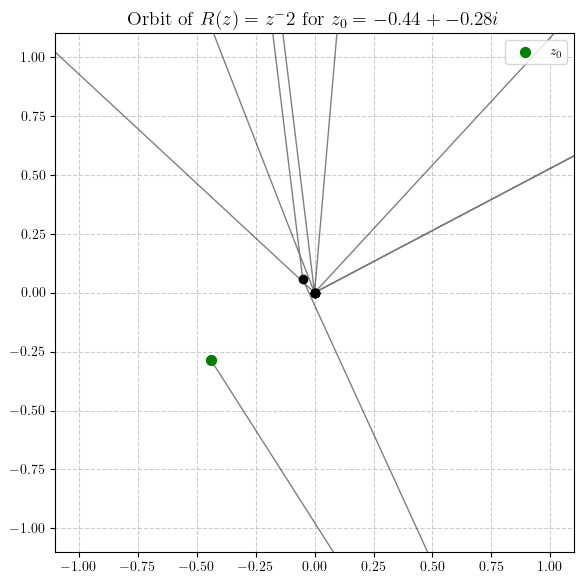

In [50]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^{-2}$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='green', s=50)

In [51]:
index = 1
for z in orbit:
    print(index, ': ', abs(z))
    index += 1

1 :  0.5239539462046187
2 :  3.642619169268511
3 :  0.07536547879050488
4 :  176.05772066021964
5 :  3.2261893270128156e-05
6 :  960771915.78747
7 :  1.083326583833431e-18
8 :  8.520816233453158e+35
9 :  1.377328714862565e-72
10 :  5.2713857266472215e+143
11 :  3.5987394722327445e-288


Si analizamos las iteraciones pares vemos que cada vez son más grandes (porque hemos empezado dentro de la circunferencia, si empezaramos fuera serían cada vez más pequeñas).

In [52]:
index = 1
for z in orbit:
    if index%2 == 0:
        print(index, ': ', abs(z))
    index += 1

2 :  3.642619169268511
4 :  176.05772066021964
6 :  960771915.78747
8 :  8.520816233453158e+35
10 :  5.2713857266472215e+143


Si analizamos las iteraciones impares vemos que cada vez son más pequeñas (porque hemos empezado dentro de la circunferencia, si empezaramos fuera serían cada vez más grandes).

In [53]:
index = 1
for z in orbit:
    if index%2 == 1:
        print(index, ': ', abs(z))
    index += 1

1 :  0.5239539462046187
3 :  0.07536547879050488
5 :  3.2261893270128156e-05
7 :  1.083326583833431e-18
9 :  1.377328714862565e-72
11 :  3.5987394722327445e-288


# Ejercicio 4

In [54]:
def R(z):
    return z**2

Función para encontrar el $z_{-n}$:

In [55]:
def find_zn_negative(R, zeta: complex, z0: complex, n: int):
    theta_zeta = np.angle(zeta)
    theta0 = np.angle(z0)
    r0 = np.abs(z0)
    
    rn = r0 ** (1 / (2**n))
    
    k_exact = (theta_zeta * (2**n) - theta0) / (2 * np.pi)
    k_optimal = round(k_exact)
    
    theta_n = (theta0 + 2 * np.pi * k_optimal) / (2**n)
    
    return rn * np.exp(1j * theta_n)

Probemos para un $\zeta$ aleatorio en la circunferencia unidad y un $z_0$ aleatorio dentro de la circunferencia unidad a encontrar $z_{-10}$.

In [56]:
r = 1
theta = np.random.uniform()

zeta = r*np.exp(2j*np.pi*theta)

In [57]:
r = np.random.uniform(0.5, 1)
theta = np.random.uniform()

z0 = r*np.exp(complex(0, 2*np.pi*theta))

In [58]:
n = 10
zn_negative = find_zn_negative(R, zeta, z0, n)

In [59]:
print(abs(zn_negative - zeta))

0.0012794496820321992


Se puede ver que $z_{-10}$ está bastante cerca de $\zeta$.

Ahora pruebo a iterar para ver que efectivamente, de $z_{-10}$ se llega a $z_0$ en 10 iteraciones.

In [61]:
max_iter = n
orbit = generate_orbit(zn_negative, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = 0.14 + 0.89i$'}>

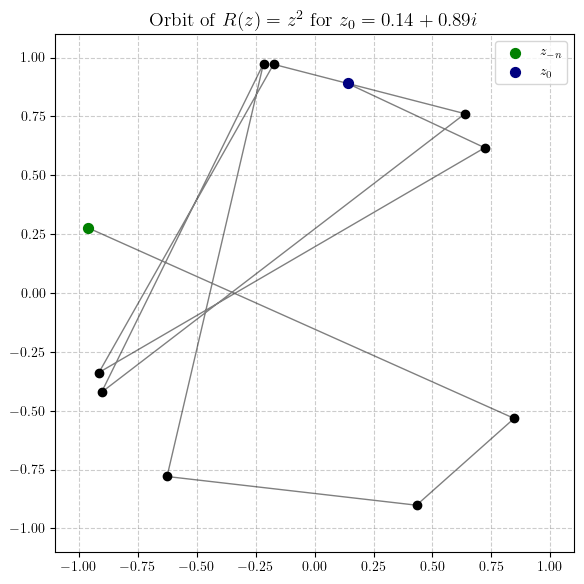

In [62]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [zn_negative], label=rf"$z_{{-n}}$", marker='o', color='green', s=50)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='navy', s=50)

In [63]:
print(abs(z0), np.angle(z0))
print(abs(orbit[-1]), np.angle(orbit[-1]))

0.9015352570277853 1.4151718294120041
0.9015352570278086 1.4151718294119007


Si siguieramos iterando llegaríamos al 0.

In [64]:
max_iter = 2*n
orbit = generate_orbit(zn_negative, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = 0.14 + 0.89i$'}>

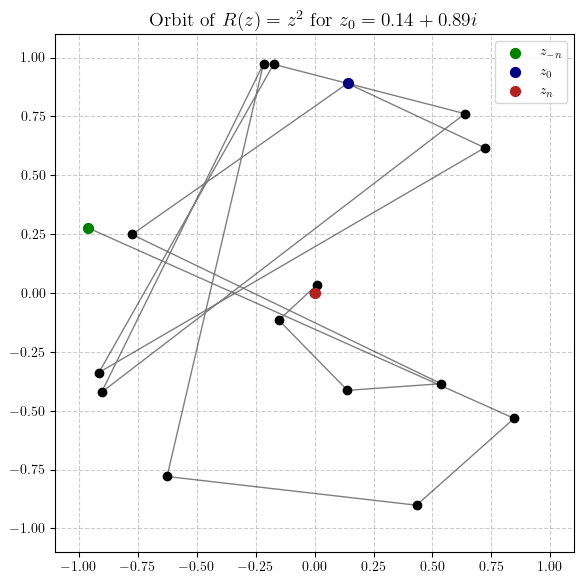

In [68]:
center = 0
max_distance_to_center = 1.1

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [zn_negative], label=rf"$z_{{-n}}$", marker='o', color='green', s=50)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='navy', s=50)
plotter.add_points(ax, [orbit[-1]], label=rf"$z_{{n}}$", marker='o', color='firebrick', s=50)

Ahora pruebo para un $z_0$ fuera de la circunferencia unidad.

In [69]:
r = 1
theta = np.random.uniform()

zeta = r*np.exp(2j*np.pi*theta)

In [70]:
r = np.random.uniform(1, 10)
theta = np.random.uniform()

z0 = r*np.exp(complex(0, 2*np.pi*theta))

In [71]:
n = 10
zn_negative = find_zn_negative(R, zeta, z0, n)

In [72]:
print(abs(zn_negative - zeta))

0.002055485742331465


Se puede ver que $z_{-10}$ está bastante cerca de $\zeta$.

Ahora pruebo a iterar para ver que efectivamente, de $z_{-10}$ se llega a $z_0$ en 10 iteraciones.

In [73]:
max_iter = n
orbit = generate_orbit(zn_negative, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = -7.52 + 2.27i$'}>

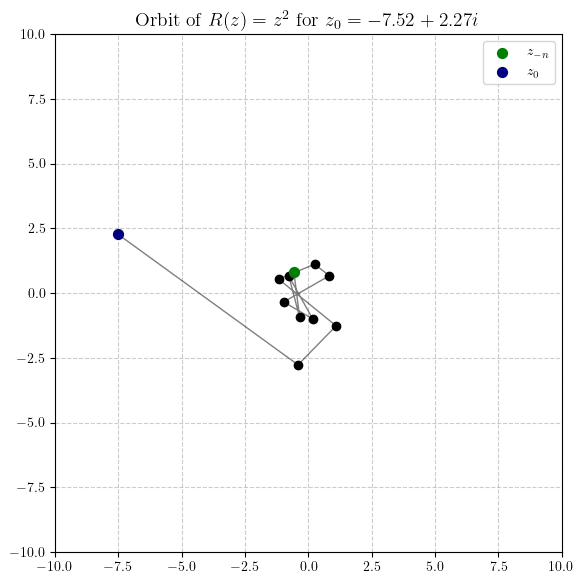

In [74]:
center = 0
max_distance_to_center = 10

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [zn_negative], label=rf"$z_{{-n}}$", marker='o', color='green', s=50)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='navy', s=50)

Si siguieramos iterando llegaríamos al $\infty$.

In [75]:
max_iter = n + 3
orbit = generate_orbit(zn_negative, R, max_iter=max_iter)

<Axes: title={'center': 'Orbit of $R(z) = z^2$ for $z_0 = -7.52 + 2.27i$'}>

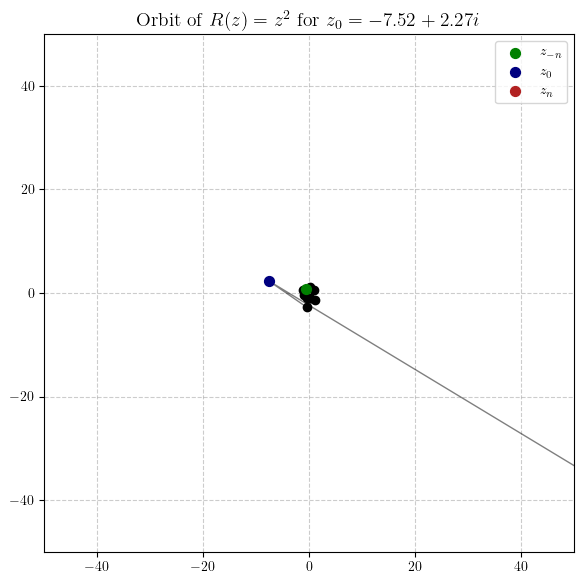

In [76]:
center = 0
max_distance_to_center = 50

xmin = center.real - max_distance_to_center
xmax = center.real + max_distance_to_center
ymin = center.imag - max_distance_to_center
ymax = center.imag + max_distance_to_center

title = rf"Orbit of $R(z) = z^2$ for $z_0 = {round(z0.real, 2)} + {round(z0.imag, 2)}i$"

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax, use_latex=True)

fig, ax = plotter.plot_orbit(orbit, title=title)
plotter.add_points(ax, [zn_negative], label=rf"$z_{{-n}}$", marker='o', color='green', s=50)
plotter.add_points(ax, [z0], label="$z_0$", marker='o', color='navy', s=50)
plotter.add_points(ax, [orbit[-1]], label=rf"$z_{{n}}$", marker='o', color='firebrick', s=50)